In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

In [ ]:
df = pd.read_csv("metadata.csv")

df['battery_num'] = df['battery_id'].str.extract('(\d+)').astype(int)

df.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9377/1502628674.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['battery_num'] = df['battery_id'].str.extract('(\d+)').astype(int)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,battery_num
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN,47
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333,47
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN,47
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734,47
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN,47


In [ ]:
batteries = [5, 6, 7, 18]

df = df[df['battery_num'].isin(batteries)]

In [ ]:
df = df[df['type'] == 'discharge']

In [ ]:
df = df.dropna(subset=['Capacity'])

In [ ]:
df['cycle'] = df.groupby('battery_num').cumcount()

In [ ]:
df = df.sort_values(['battery_num', 'cycle']).reset_index(drop=True)

In [ ]:
df['Capacity'] = pd.to_numeric(df['Capacity'])

initial_capacity = df.groupby('battery_num')['Capacity'].first().to_dict()

df['SOH'] = df.apply(
    lambda x: x['Capacity'] / initial_capacity[x['battery_num']],
    axis=1
)

In [ ]:
df = pd.read_csv("metadata.csv")

df.columns = df.columns.str.strip()

# Converting Capacity to float
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')

# Extracting battery number
df['battery_num'] = df['battery_id'].str.extract('(\d+)').astype(int)

# Filter required batteries
batteries = [5, 6, 7, 18]
df = df[df['battery_num'].isin(batteries)]

# Keeping only discharge
df = df[df['type'] == 'discharge']

# Droping NaNs AFTER conversion
df = df.dropna(subset=['Capacity'])

# Creating cycle
df['cycle'] = df.groupby('battery_num').cumcount()

# Sorting
df = df.sort_values(['battery_num', 'cycle']).reset_index(drop=True)

# Compute SOH
initial_capacity = df.groupby('battery_num')['Capacity'].first().to_dict()

df['SOH'] = df.apply(
    lambda x: x['Capacity'] / initial_capacity[x['battery_num']],
    axis=1
)

print("SOH created successfully")
print(df[['battery_num', 'cycle', 'Capacity', 'SOH']].head())

SOH created successfully
   battery_num  cycle  Capacity       SOH
0            5      0  1.856487  1.000000
1            5      1  1.846327  0.994527
2            5      2  1.835349  0.988614
3            5      3  1.835263  0.988567
4            5      4  1.834646  0.988235


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9377/3095527314.py:9: SyntaxWarning: invalid escape sequence '\d'
  df['battery_num'] = df['battery_id'].str.extract('(\d+)').astype(int)


In [ ]:
df[['battery_num', 'cycle', 'Capacity', 'SOH']].head()

,battery_num,cycle,Capacity,SOH
0,5,0,1.856487,1.000000
1,5,1,1.846327,0.994527
2,5,2,1.835349,0.988614
3,5,3,1.835263,0.988567
4,5,4,1.834646,0.988235


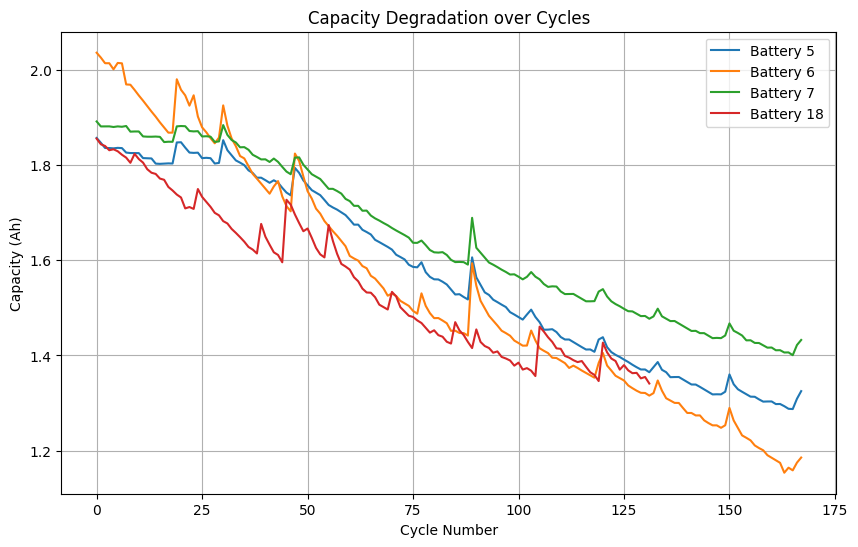

In [ ]:
plt.figure(figsize=(10,6))

for battery in batteries:
    battery_df = df[df['battery_num'] == battery]

    cycles = battery_df['cycle'].values
    capacity = battery_df['Capacity'].values

    plt.plot(cycles, capacity, label=f'Battery {battery}')

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation over Cycles")
plt.legend()
plt.grid()
plt.show()

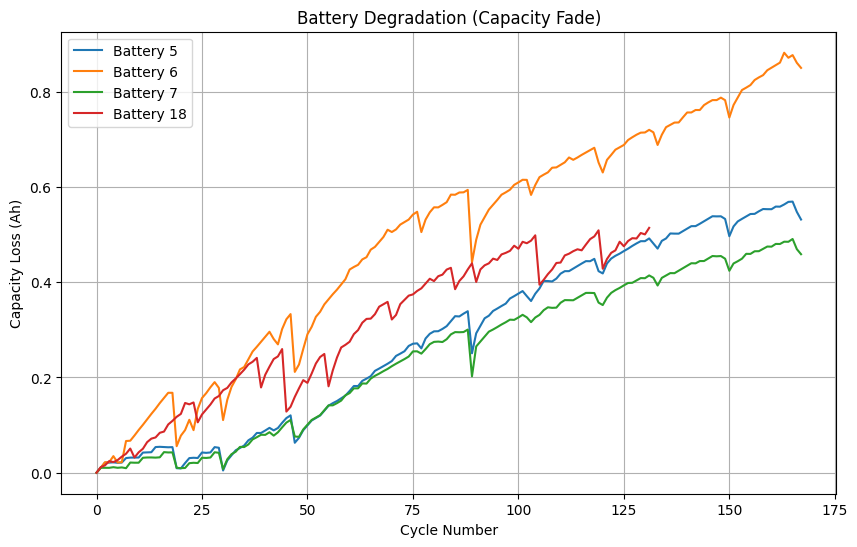

In [ ]:
plt.figure(figsize=(10,6))

for battery in batteries:
    battery_df = df[df['battery_num'] == battery]

    cycles = battery_df['cycle'].values
    capacity = battery_df['Capacity'].values

    initial_cap = capacity[0]
    degradation = initial_cap - capacity

    plt.plot(cycles, degradation, label=f'Battery {battery}')

plt.xlabel("Cycle Number")
plt.ylabel("Capacity Loss (Ah)")
plt.title("Battery Degradation (Capacity Fade)")
plt.legend()
plt.grid()
plt.show()

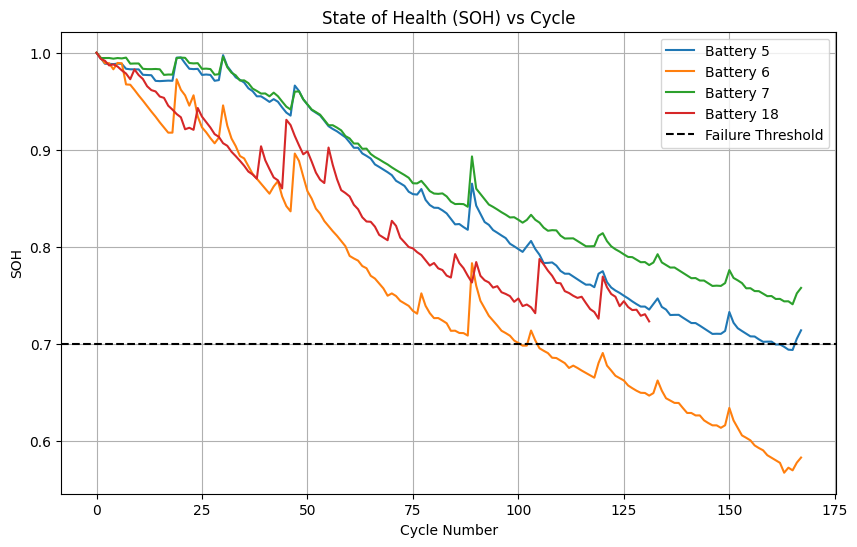

In [ ]:
plt.figure(figsize=(10,6))

for battery in batteries:
    battery_df = df[df['battery_num'] == battery]

    cycles = battery_df['cycle'].values
    soh = battery_df['SOH'].values

    plt.plot(cycles, soh, label=f'Battery {battery}')

# Failure threshold
plt.axhline(y=0.7, linestyle='--', color='black', label='Failure Threshold')

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("State of Health (SOH) vs Cycle")
plt.legend()
plt.grid()
plt.show()

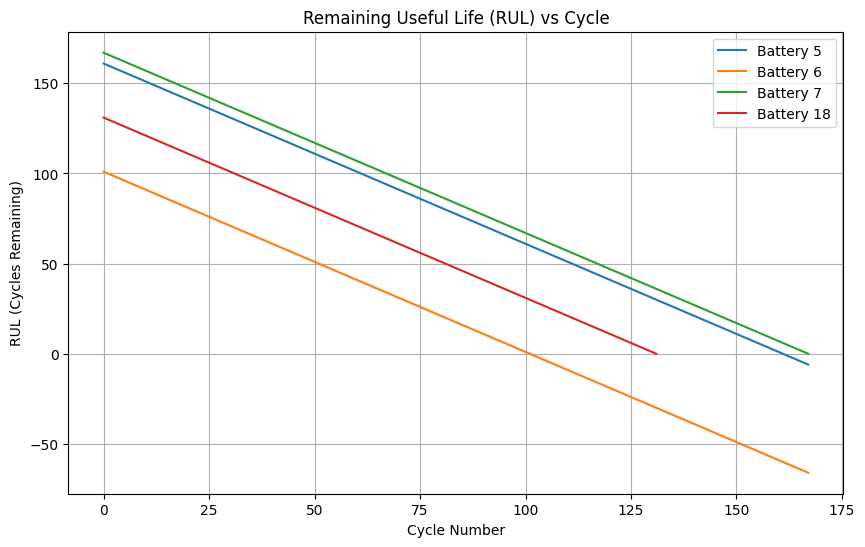

In [ ]:
threshold = 0.7

plt.figure(figsize=(10,6))

for battery in batteries:
    battery_df = df[df['battery_num'] == battery]

    soh = battery_df['SOH'].values
    cycles = battery_df['cycle'].values

    # Finding failure cycle
    failure_idx = np.where(soh <= threshold)[0]

    if len(failure_idx) > 0:
        failure_cycle = failure_idx[0]
    else:
        failure_cycle = len(soh) - 1

    # Compute RUL
    rul = failure_cycle - cycles

    plt.plot(cycles, rul, label=f'Battery {battery}')

plt.xlabel("Cycle Number")
plt.ylabel("RUL (Cycles Remaining)")
plt.title("Remaining Useful Life (RUL) vs Cycle")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def create_sequences(data, window=20):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [ ]:
# CNN + LSTM model

def build_model(input_shape):
    model = Sequential()

    model.add(Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(2))

    model.add(LSTM(64))
    model.add(Dropout(0.2))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    return model

In [ ]:
def compute_metrics(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return mape, rmse, mae

def calculate_rul(soh, threshold=0.7):
    for i in range(len(soh)):
        if soh[i] <= threshold:
            return i
    return len(soh)

def calculate_ae(real_rul, pred_rul):
    return abs(real_rul - pred_rul)

In [ ]:
window = 20
results = {}

for battery in batteries:
    print(f"\nProcessing Battery {battery}")

    data = df[df['battery_num'] == battery]['SOH'].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = create_sequences(data_scaled, window)

    split = int(0.7 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_model((window, 1))
    #model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)
    history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

    results[battery] = {}

    for start in [50, 75, 100]:

        test_seq = data_scaled[start:start+window].copy()
        preds = []

        for _ in range(len(data_scaled) - start - window):
            pred = model.predict(test_seq.reshape(1, window, 1), verbose=0)
            preds.append(pred[0][0])

            test_seq = np.append(test_seq[1:], pred, axis=0)

        preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
        real = data[start+window:start+window+len(preds)]

        mape, rmse, mae = compute_metrics(real, preds)

        real_rul = calculate_rul(real.flatten())
        pred_rul = calculate_rul(preds.flatten())
        ae = calculate_ae(real_rul, pred_rul)

        results[battery][start] = {
            "MAPE": mape,
            "RMSE": rmse,
            "MAE": mae,
            "AE": ae,
            "real": real,
            "pred": preds
        }


Processing Battery 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - loss: 0.1608 - val_loss: 0.0172
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0362 - val_loss: 0.0216
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0126 - val_loss: 0.0060
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0211 - val_loss: 0.0101
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0101 - val_loss: 0.0195
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0136 - val_loss: 0.0088
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0068
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.0079
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0069 - val_loss: 0.0049
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0082 - val_loss: 0.0034
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0050 - val_loss: 0.0024
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0060 - val_loss: 0.0015


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.1647 - val_loss: 0.0038
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0189 - val_loss: 0.0379
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0126 - val_loss: 0.0091
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0123 - val_loss: 0.0082
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0172
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0080 - val_loss: 0.0127
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0060 - val_loss: 0.0073
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 0.0076
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0038 - val_loss: 0.0071
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0045 - val_loss: 0.0047
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0041 - val_loss: 0.0028
Epoch 13/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.2420 - val_loss: 0.0028
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0382 - val_loss: 0.0408
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0220 - val_loss: 0.0118
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0188 - val_loss: 0.0087
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0099 - val_loss: 0.0161
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0144
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0076 - val_loss: 0.0085
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0071 - val_loss: 0.0078
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0052 - val_loss: 0.0036
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0047 - val_loss: 0.0023
Epoch 13/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 0.2173 - val_loss: 0.0032
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0591 - val_loss: 0.0156
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0264 - val_loss: 0.0356
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0235 - val_loss: 0.0151
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0149 - val_loss: 0.0081
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0155 - val_loss: 0.0095
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0130 - val_loss: 0.0138
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0101 - val_loss: 0.0139
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0095 - val_loss: 0.0103
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0079 - val_loss: 0.0082
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0091 - val_loss: 0.0076
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0082 - val_loss: 0.0078
Epoch 13/50

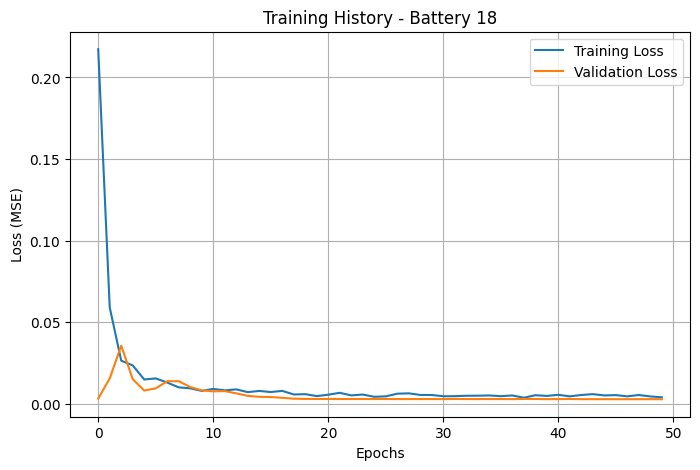

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title(f"Training History - Battery {battery}")
plt.legend()
plt.grid()

plt.show()

In [ ]:
histories = {}

In [ ]:
histories[battery] = history

In [ ]:
for battery in batteries:
    print(f"Processing Battery {battery}")

    battery_df = df[df['battery_num'] == battery]
    data = battery_df['SOH'].values.reshape(-1, 1)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = create_sequences(data_scaled, window)

    split = int(0.7 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_model((window, 1))

    # STORE HISTORY HERE
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_data=(X_test, y_test),
        verbose=1
    )

    histories[battery] = history

Processing Battery 5
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.1140 - val_loss: 0.0334
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0333 - val_loss: 0.0113
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0172 - val_loss: 0.0057
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0103 - val_loss: 0.0150
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0121 - val_loss: 0.0084
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0090 - val_loss: 0.0052
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0106 - val_loss: 0.0069
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0071 - val_loss: 0.0041
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0057 - val_loss: 0.0026
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0045 - val_loss: 0.0015
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0046 - val_loss: 0.0012
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0051 - val_loss: 8.7877e-04
Epoch 13

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.2210 - val_loss: 0.0029
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0540 - val_loss: 0.0240
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0239 - val_loss: 0.0283
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0105 - val_loss: 0.0085
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0166 - val_loss: 0.0107
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0156
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0077 - val_loss: 0.0135
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0069 - val_loss: 0.0087
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0059 - val_loss: 0.0074
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0051 - val_loss: 0.0073
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0065 - val_loss: 0.0042
Epoch 13/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.2145 - val_loss: 0.0047
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0279 - val_loss: 0.0257
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0166 - val_loss: 0.0056
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0154 - val_loss: 0.0054
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0098 - val_loss: 0.0106
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - val_loss: 0.0047
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0078 - val_loss: 0.0034
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0072 - val_loss: 0.0049
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0044 - val_loss: 0.0022
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0042 - val_loss: 0.0015
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0042 - val_loss: 9.6757e-04
Epoch 13

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.1566 - val_loss: 0.0031
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0258 - val_loss: 0.0159
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0253 - val_loss: 0.0176
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0108 - val_loss: 0.0070
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0132 - val_loss: 0.0052
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0124 - val_loss: 0.0075
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0094 - val_loss: 0.0098
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0109 - val_loss: 0.0077
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0079 - val_loss: 0.0049
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0102 - val_loss: 0.0050
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0063 - val_loss: 0.0049
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0067 - val_loss: 0.0047
Epoch 13/50


In [ ]:
print(histories.keys())

dict_keys([18, 5, 6, 7])


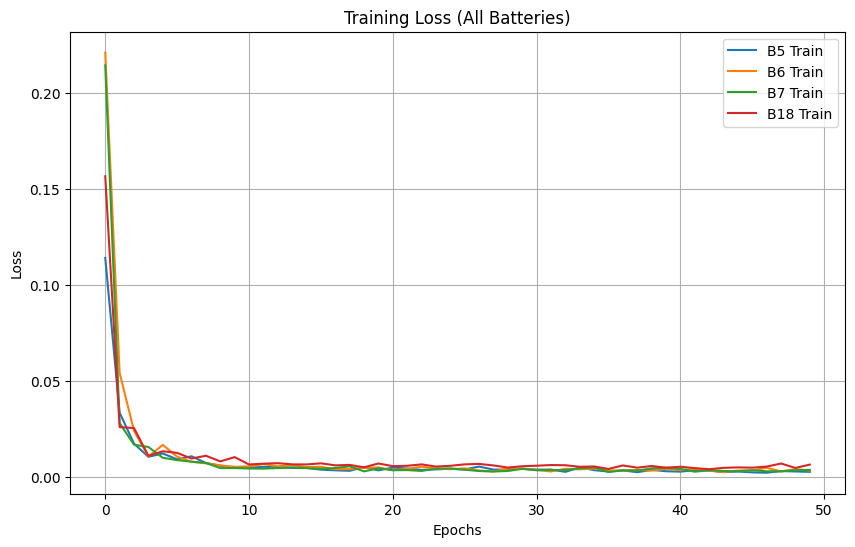

In [ ]:
plt.figure(figsize=(10,6))

for battery in batteries:
    if battery in histories:
        plt.plot(histories[battery].history['loss'], label=f'B{battery} Train')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss (All Batteries)")
plt.legend()
plt.grid()

plt.show()

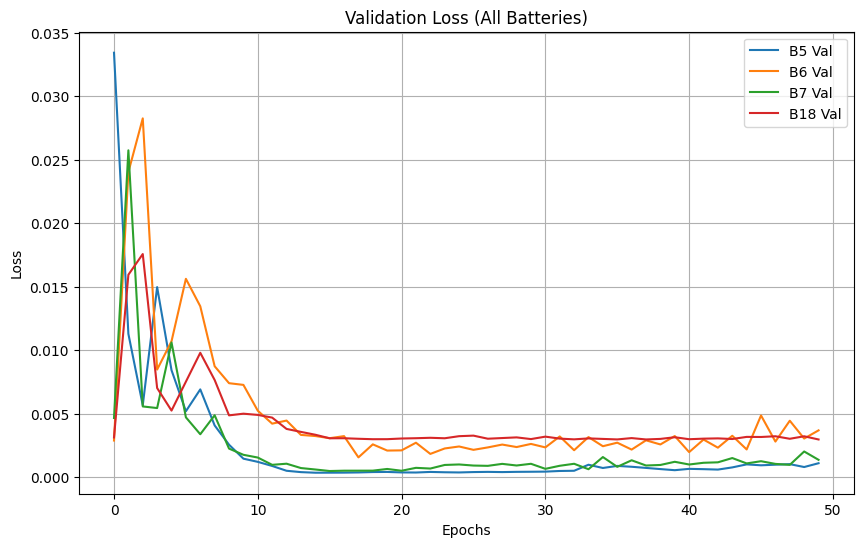

In [ ]:
plt.figure(figsize=(10,6))

for battery in batteries:
    if battery in histories:
        plt.plot(histories[battery].history['val_loss'], label=f'B{battery} Val')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss (All Batteries)")
plt.legend()
plt.grid()

plt.show()

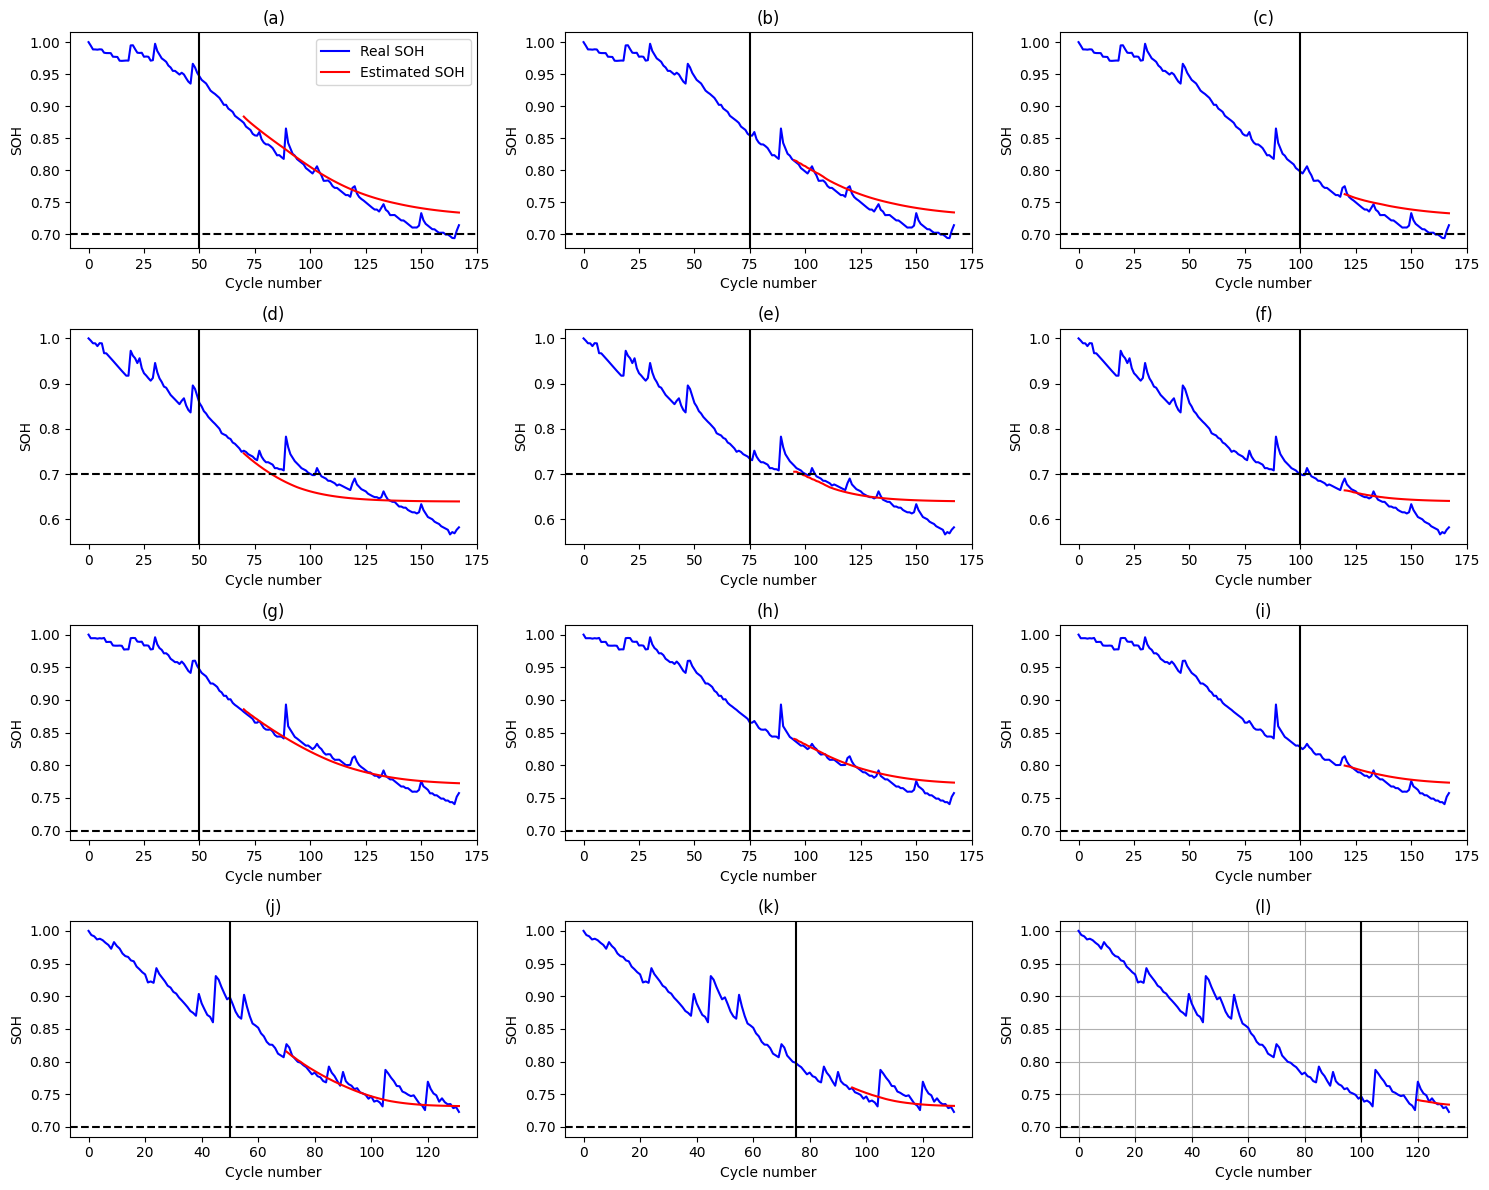

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

plot_idx = 0

for battery in batteries:
    battery_df = df[df['battery_num'] == battery]

    full_soh = battery_df['SOH'].values
    cycles = np.arange(len(full_soh))

    for start in [50, 75, 100]:

        res = results[battery][start]
        pred = res["pred"].flatten()

        ax = axes[plot_idx]

        # REAL SOH
        ax.plot(cycles, full_soh, color='blue', label='Real SOH')

        # PREDICTION STARTS AT CORRECT CYCLE
        pred_cycles = np.arange(start + window, start + window + len(pred))
        ax.plot(pred_cycles, pred, color='red', label='Estimated SOH')

        # INITIAL LINE (vertical)
        ax.axvline(x=start, color='black')

        # FAILURE LINE
        ax.axhline(y=0.7, linestyle='--', color='black')

        ax.set_xlabel("Cycle number")
        ax.set_ylabel("SOH")

        # Labels
        labels = ['(a)','(b)','(c)','(d)','(e)','(f)',
                  '(g)','(h)','(i)','(j)','(k)','(l)']
        ax.set_title(labels[plot_idx])

        if plot_idx == 0:
            ax.legend()

        plot_idx += 1
        plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\nFINAL RESULTS\n")

for metric in ["MAPE", "RMSE", "MAE", "AE"]:
    print(f"\n{metric}")

    print("Start | B5 | B6 | B7 | B18")

    for start in [50, 75, 100]:
        row = [str(start)]

        for battery in batteries:
            val = results[battery][start][metric]
            row.append(f"{val:.4f}" if metric != "AE" else str(val))

        print(" | ".join(row))


FINAL RESULTS


MAPE
Start | B5 | B6 | B7 | B18
50 | 0.0200 | 0.0449 | 0.0189 | 0.0146
75 | 0.0243 | 0.0620 | 0.0126 | 0.0163
100 | 0.0250 | 0.0716 | 0.0182 | 0.0112

RMSE
Start | B5 | B6 | B7 | B18
50 | 0.0176 | 0.0386 | 0.0182 | 0.0134
75 | 0.0201 | 0.0464 | 0.0133 | 0.0153
100 | 0.0201 | 0.0509 | 0.0167 | 0.0105

MAE
Start | B5 | B6 | B7 | B18
50 | 0.0149 | 0.0281 | 0.0152 | 0.0111
75 | 0.0177 | 0.0383 | 0.0097 | 0.0123
100 | 0.0178 | 0.0432 | 0.0138 | 0.0083

AE
Start | B5 | B6 | B7 | B18
50 | 7 | 0 | 0 | 0
75 | 7 | 10 | 0 | 0
100 | 7 | 0 | 0 | 0


In [ ]:
# Sequence Flatting
def reshape_for_ml(X):
    return X.reshape(X.shape[0], -1)

In [ ]:
# Training Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

def train_ml_models(X_train, y_train):

    X_train_flat = reshape_for_ml(X_train)

    models = {}

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_flat, y_train)
    models['LR'] = lr

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100)
    rf.fit(X_train_flat, y_train)
    models['RF'] = rf

    # XGBoost
    xg_model = xgb.XGBRegressor(n_estimators=100)
    xg_model.fit(X_train_flat, y_train)
    models['XGB'] = xg_model

    # LightGBM
    lgb_model = lgb.LGBMRegressor(n_estimators=100)
    lgb_model.fit(X_train_flat, y_train)
    models['LGBM'] = lgb_model

    return models

In [ ]:
# LSTM
from tensorflow.keras.layers import LSTM

def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
# RNN
from tensorflow.keras.layers import SimpleRNN

def build_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(64, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


# ANN
def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
def predict_recursive(model, data_scaled, start, window, scaler, model_type="dl"):

    test_seq = data_scaled[start:start+window].copy()
    preds = []

    for _ in range(len(data_scaled) - start - window):

        if model_type == "ml":  # ML + ANN
            pred = model.predict(test_seq.reshape(1, -1))[0]

        elif model_type == "rnn":  # RNN
            pred = model.predict(test_seq.reshape(1, window, 1), verbose=0)[0][0]

        else:  # LSTM / CNN-LSTM
            pred = model.predict(test_seq.reshape(1, window, 1), verbose=0)[0][0]

        preds.append(pred)
        test_seq = np.append(test_seq[1:], pred)

    preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
    return preds

In [ ]:
# Unified Prediction Function
def predict_recursive(model, data_scaled, start, window, scaler, model_type="dl"):

    test_seq = data_scaled[start:start+window].copy()
    preds = []

    for _ in range(len(data_scaled) - start - window):

        if model_type == "ml":
            pred = model.predict(test_seq.reshape(1, -1))[0]
        else:
            pred = model.predict(test_seq.reshape(1, window, 1), verbose=0)[0][0]

        preds.append(pred)

        test_seq = np.append(test_seq[1:], pred)

    preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
    return preds

In [ ]:
# Train DL models
lstm = build_lstm((window,1))
lstm.fit(X_train, y_train, epochs=30, verbose=0)

rnn = build_rnn((window,1))
rnn.fit(X_train, y_train, epochs=30, verbose=0)

# ANN needs flattened input
X_train_ann = X_train.reshape(X_train.shape[0], -1)
ann = build_ann(X_train_ann.shape[1])
ann.fit(X_train_ann, y_train, epochs=30, verbose=0)

cnn_lstm = build_model((window,1))
cnn_lstm.fit(X_train, y_train, epochs=30, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
batteries = [5, 6, 7, 18]

all_results = {}

for battery in batteries:
    print(f"\nProcessing battery {battery}")

    data = df[df['battery_num'] == battery]['SOH'].values.reshape(-1,1)

    if len(data) == 0:
        print(f"Skipping battery {battery} (no data)")
        continue

    all_results[battery] = {}

    try:
        scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data)

        X, y = create_sequences(data_scaled, window)

        split = int(0.7 * len(X))
        X_train, y_train = X[:split], y[:split]

        # Train models here (ANN, RNN, LSTM, CNN-LSTM)

        for start in [50, 75, 100]:
            all_results[battery][start] = {}

            # predictions here

    except Exception as e:
        print(f"Error in battery {battery}: {e}")


Processing battery 5

Processing battery 6

Processing battery 7

Processing battery 18


In [ ]:
for battery in batteries:
    print(f"\n🔍 Processing battery {battery}")

    try:
        data = df[df['battery_num'] == battery]['SOH'].values.reshape(-1,1)
        print("Data length:", len(data))

        scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data)

        X, y = create_sequences(data_scaled, window)
        print("Sequence length:", len(X))

        split = int(0.7 * len(X))
        X_train, y_train = X[:split], y[:split]

        # Train models (your existing code)

        all_results[battery] = {}

        for start in [50, 75, 100]:
            print(f"Start {start}")
            all_results[battery][start] = {}

            # your predictions here

    except Exception as e:
        print(f"❌ ERROR in battery {battery}: {e}")
        continue


🔍 Processing battery 5
Data length: 168
Sequence length: 148
Start 50
Start 75
Start 100

🔍 Processing battery 6
Data length: 168
Sequence length: 148
Start 50
Start 75
Start 100

🔍 Processing battery 7
Data length: 168
Sequence length: 148
Start 50
Start 75
Start 100

🔍 Processing battery 18
Data length: 132
Sequence length: 112
Start 50
Start 75
Start 100


In [ ]:
all_results = {}   # ✅ ONLY ONCE

for battery in batteries:

    print(f"\nProcessing battery {battery}")

    data = df[df['battery_num'] == battery]['SOH'].values.reshape(-1,1)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = create_sequences(data_scaled, window)

    split = int(0.7 * len(X))
    X_train, y_train = X[:split], y[:split]

    # Train models
    ml_models = train_ml_models(X_train, y_train)

    lstm = build_lstm((window,1))
    lstm.fit(X_train, y_train, epochs=30, verbose=0)

    rnn = build_rnn((window,1))
    rnn.fit(X_train, y_train, epochs=30, verbose=0)

    X_train_ann = X_train.reshape(X_train.shape[0], -1)
    ann = build_ann(X_train_ann.shape[1])
    ann.fit(X_train_ann, y_train, epochs=30, verbose=0)

    cnn_lstm = build_model((window,1))
    cnn_lstm.fit(X_train, y_train, epochs=30, verbose=0)

    # ✅ initialize per battery
    all_results[battery] = {}

    for start in [50, 75, 100]:

        all_results[battery][start] = {}

        # ML
        for name, model in ml_models.items():
            preds = predict_recursive(model, data_scaled, start, window, scaler, "ml")
            all_results[battery][start][name] = preds

        # ANN
        all_results[battery][start]['ANN'] = predict_recursive(
            ann, data_scaled, start, window, scaler, "ml"
        )

        # RNN
        all_results[battery][start]['RNN'] = predict_recursive(
            rnn, data_scaled, start, window, scaler, "rnn"
        )

        # LSTM
        all_results[battery][start]['LSTM'] = predict_recursive(
            lstm, data_scaled, start, window, scaler
        )

        # CNN-LSTM
        all_results[battery][start]['CNN-LSTM'] = predict_recursive(
            cnn_lstm, data_scaled, start, window, scaler
        )


Processing battery 5


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 720
[LightGBM] [Info] Number of data points in the train set: 103, number of used features: 20
[LightGBM] [Info] Start training from score 0.594528
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRe

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [ ]:
print(all_results.keys())

dict_keys([5, 6, 7, 18])


In [ ]:
# Comparision
all_results = {}

for battery in batteries:
    print(f"\nBattery {battery}")

    data = df[df['battery_num'] == battery]['SOH'].values.reshape(-1,1)

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    X, y = create_sequences(data_scaled, window)

    split = int(0.7 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Train ML models
    ml_models = train_ml_models(X_train, y_train)

    # Train DL models
    lstm = build_lstm((window,1))
    lstm.fit(X_train, y_train, epochs=30, verbose=0)

    cnn_lstm = build_model((window,1))
    cnn_lstm.fit(X_train, y_train, epochs=30, verbose=0)

    # ANN
    all_results[battery][start]['ANN'] = predict_recursive(
        ann, data_scaled, start, window, scaler, model_type="ml"
    )

    # RNN
    all_results[battery][start]['RNN'] = predict_recursive(
        rnn, data_scaled, start, window, scaler, model_type="rnn"
    )

    for start in [50, 75, 100]:

        all_results[battery][start] = {}

        for name, model in ml_models.items():
            preds = predict_recursive(model, data_scaled, start, window, scaler, "ml")
            all_results[battery][start][name] = preds

        # LSTM
        all_results[battery][start]['LSTM'] = predict_recursive(lstm, data_scaled, start, window, scaler)

        # CNN-LSTM
        all_results[battery][start]['CNN-LSTM'] = predict_recursive(cnn_lstm, data_scaled, start, window, scaler)


Battery 5


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 720
[LightGBM] [Info] Number of data points in the train set: 103, number of used features: 20
[LightGBM] [Info] Start training from score 0.594528
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

KeyError: 5

In [ ]:
all_results[battery] = {}

for start in [50, 75, 100]:

    # ✅ INITIALIZE FIRST
    all_results[battery][start] = {}

    # ML models
    for name, model in ml_models.items():
        preds = predict_recursive(model, data_scaled, start, window, scaler, "ml")
        all_results[battery][start][name] = preds

    # ANN
    all_results[battery][start]['ANN'] = predict_recursive(
        ann, data_scaled, start, window, scaler, model_type="ml"
    )

    # RNN
    all_results[battery][start]['RNN'] = predict_recursive(
        rnn, data_scaled, start, window, scaler, model_type="rnn"
    )

    # LSTM
    all_results[battery][start]['LSTM'] = predict_recursive(
        lstm, data_scaled, start, window, scaler
    )

    # CNN-LSTM
    all_results[battery][start]['CNN-LSTM'] = predict_recursive(
        cnn_lstm, data_scaled, start, window, scaler
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

In [ ]:
print(all_results.keys())

dict_keys([5, 6, 7, 18])


In [ ]:
# Metrics Table
def compute_metrics(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return mape, rmse, mae

In [ ]:
batteries = [5, 6, 7, 18]

In [ ]:
for battery in batteries:
    metrics_results[battery] = {}

    real_full = df[df['battery_num']==battery]['SOH'].values.reshape(-1,1)

    for start in [50, 75, 100]:
        metrics_results[battery][start] = {}

        if start not in all_results[battery]:
            continue

        for model_name, preds in all_results[battery][start].items():

            real = real_full[start+window : start+window+len(preds)]

            mape, rmse, mae = compute_metrics(real, preds)

            real_rul = calculate_rul(real.flatten())
            pred_rul = calculate_rul(preds.flatten())
            ae = calculate_ae(real_rul, pred_rul)

            metrics_results[battery][start][model_name] = {
                "MAPE": mape,
                "RMSE": rmse,
                "MAE": mae,
                "AE": ae
            }

In [ ]:
metrics_results = {}

for battery in batteries:
    metrics_results[battery] = {}

    real_full = df[df['battery_num']==battery]['SOH'].values.reshape(-1,1)

    for start in [50, 75, 100]:
        metrics_results[battery][start] = {}

        if start not in all_results[battery]:
          continue

        for model_name, preds in all_results[battery][start].items():

            real = real_full[start+window:start+window+len(preds)]

            mape, rmse, mae = compute_metrics(real, preds)

            real_rul = calculate_rul(real.flatten())
            pred_rul = calculate_rul(preds.flatten())
            ae = calculate_ae(real_rul, pred_rul)

            metrics_results[battery][start][model_name] = {
                "MAPE": mape,
                "RMSE": rmse,
                "MAE": mae,
                "AE": ae
            }

In [ ]:
for metric in ["MAPE", "RMSE", "MAE", "AE"]:
    print(f"\n========== {metric} ==========")

    for start in [50, 75, 100]:
        print(f"\nStart = {start}")
        print("Model | B5 | B6 | B7 | B18")

        for model in ['LR','RF','XGB','LGBM','ANN','RNN','LSTM','CNN-LSTM']:
            row = [model]

            for battery in batteries:
                val = metrics_results[battery][start][model][metric]

                if metric != "AE":
                    row.append(f"{val:.4f}")
                else:
                    row.append(str(val))

            print(" | ".join(row))


========== MAPE ==========

Start = 50
Model | B5 | B6 | B7 | B18
LR | 0.0129 | 0.0199 | 0.0059 | 0.0299
RF | 0.0280 | 0.0443 | 0.0234 | 0.0122
XGB | 0.0829 | 0.0824 | 0.0268 | 0.0109
LGBM | 0.0388 | 0.0519 | 0.0293 | 0.0235
ANN | 0.0742 | 0.0843 | 0.0891 | 0.0195
RNN | 0.1178 | 0.1725 | 0.0282 | 0.1085
LSTM | 0.0126 | 0.0338 | 0.0226 | 0.0312
CNN-LSTM | 0.0249 | 0.0293 | 0.0089 | 0.0182

Start = 75
Model | B5 | B6 | B7 | B18
LR | 0.0131 | 0.0294 | 0.0100 | 0.0453
RF | 0.0358 | 0.0788 | 0.0304 | 0.0186
XGB | 0.0402 | 0.1079 | 0.0336 | 0.0165
LGBM | 0.0475 | 0.0628 | 0.0360 | 0.0337
ANN | 0.0632 | 0.0914 | 0.0940 | 0.0242
RNN | 0.0424 | 0.1594 | 0.0400 | 0.1099
LSTM | 0.0093 | 0.0430 | 0.0241 | 0.0273
CNN-LSTM | 0.0120 | 0.0387 | 0.0099 | 0.0216

Start = 100
Model | B5 | B6 | B7 | B18
LR | 0.0156 | 0.0318 | 0.0065 | 0.0357
RF | 0.0509 | 0.0775 | 0.0425 | 0.0211
XGB | 0.0603 | 0.0966 | 0.0507 | 0.0189
LGBM | 0.0679 | 0.0913 | 0.0522 | 0.0404
ANN | 0.0468 | 0.0916 | 0.0980 | 0.0187
RNN |

In [ ]:
def plot_model_results(battery, start):

    real = df[df['battery_num']==battery]['SOH'].values

    models = all_results[battery][start].keys()

    fig, axes = plt.subplots(2, 3, figsize=(15,8))
    axes = axes.flatten()

    for idx, model_name in enumerate(models):

        preds = all_results[battery][start][model_name]

        ax = axes[idx]

        # Real curve
        ax.plot(real, color='blue', label='Real SOH')

        # Prediction
        pred_cycles = np.arange(start+window, start+window+len(preds))
        ax.plot(pred_cycles, preds, color='red', label=model_name)

        # Failure line
        ax.axhline(y=0.7, linestyle='--', color='black')

        # Start line
        ax.axvline(x=start, color='black')

        ax.set_title(model_name)
        ax.set_xlabel("Cycle")
        ax.set_ylabel("SOH")

        if idx == 0:
            ax.legend()

    plt.suptitle(f"Battery {battery} - Start {start}", fontsize=14)
    plt.tight_layout()
    plt.show()

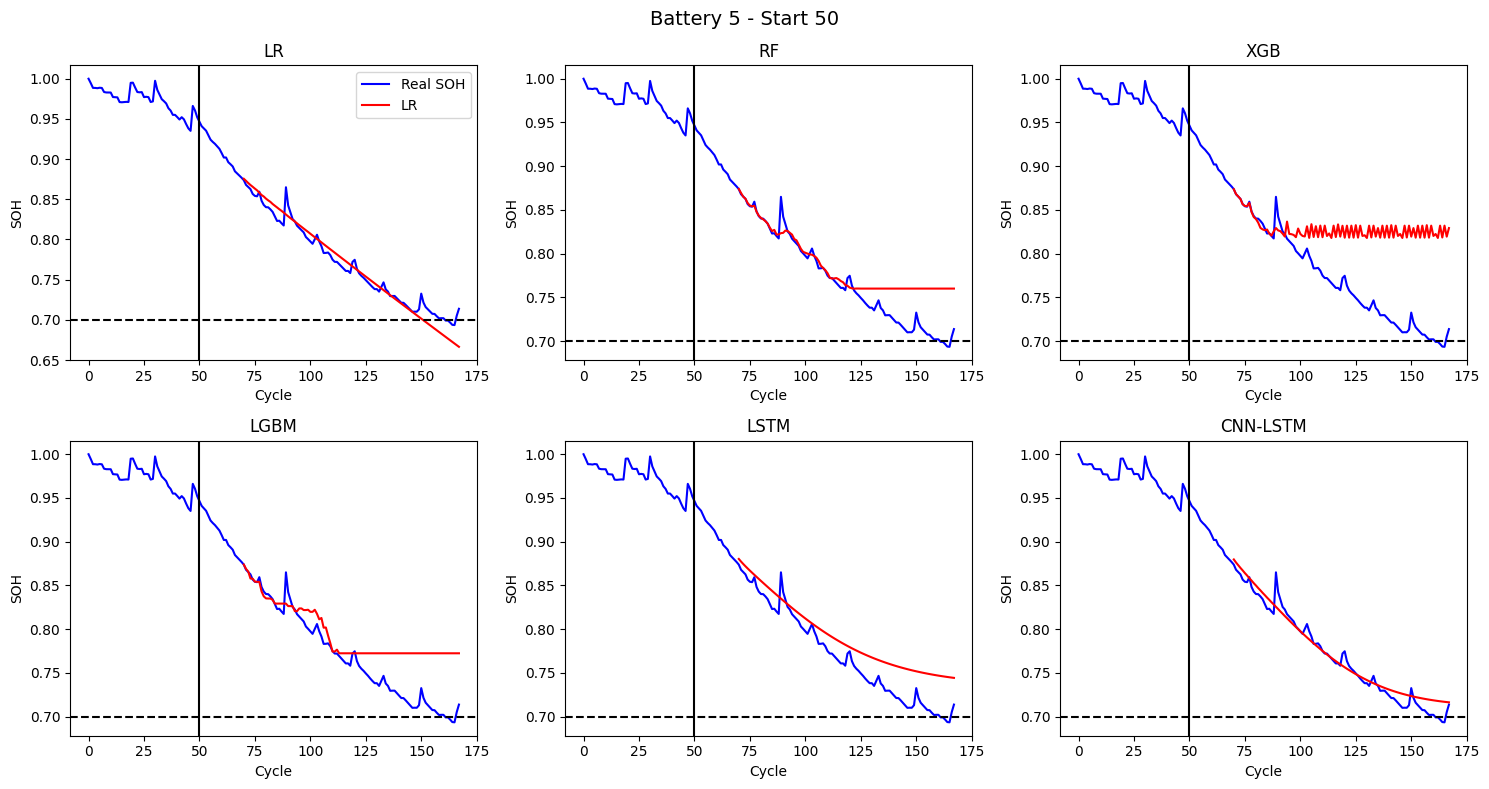

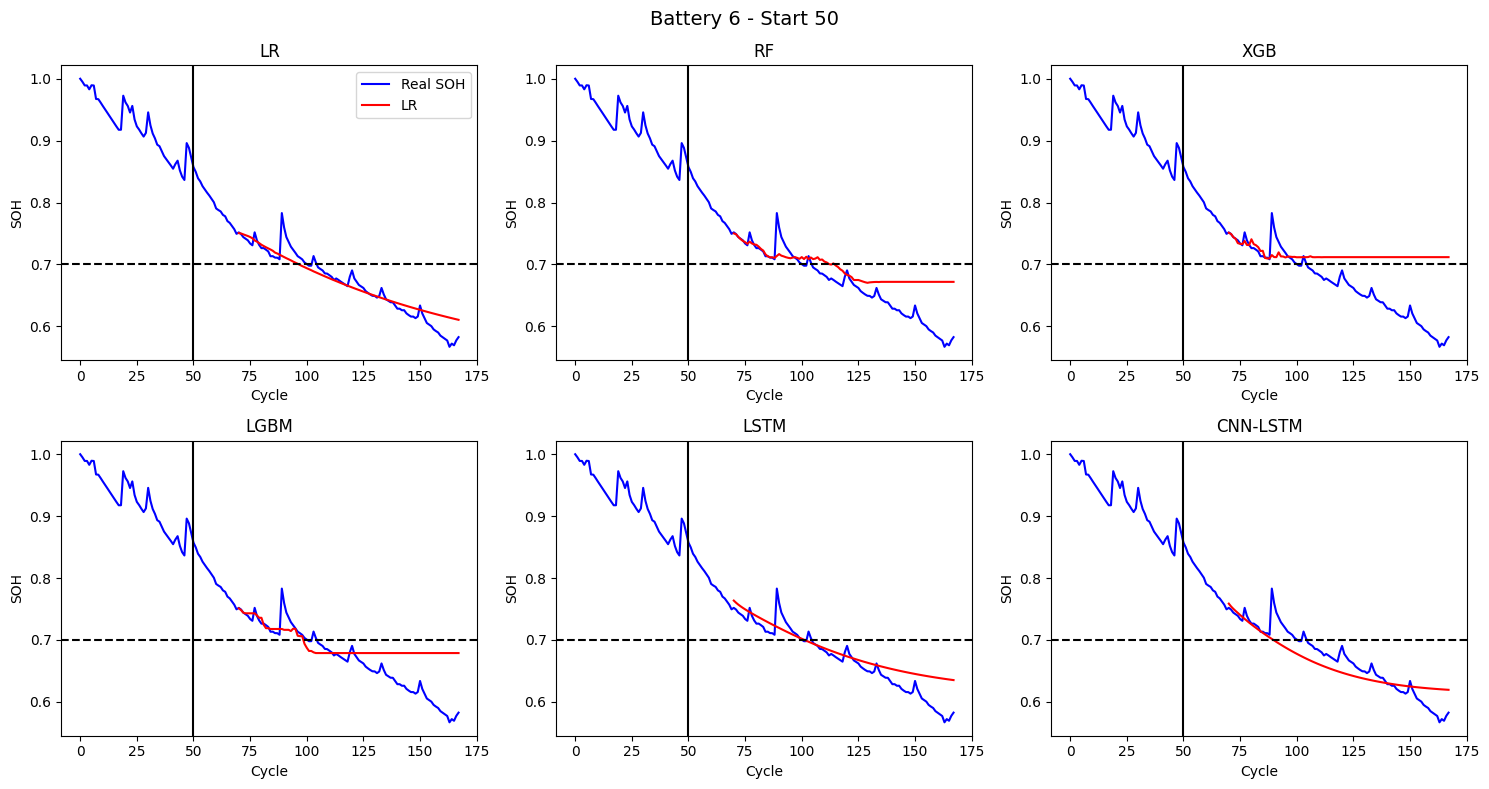

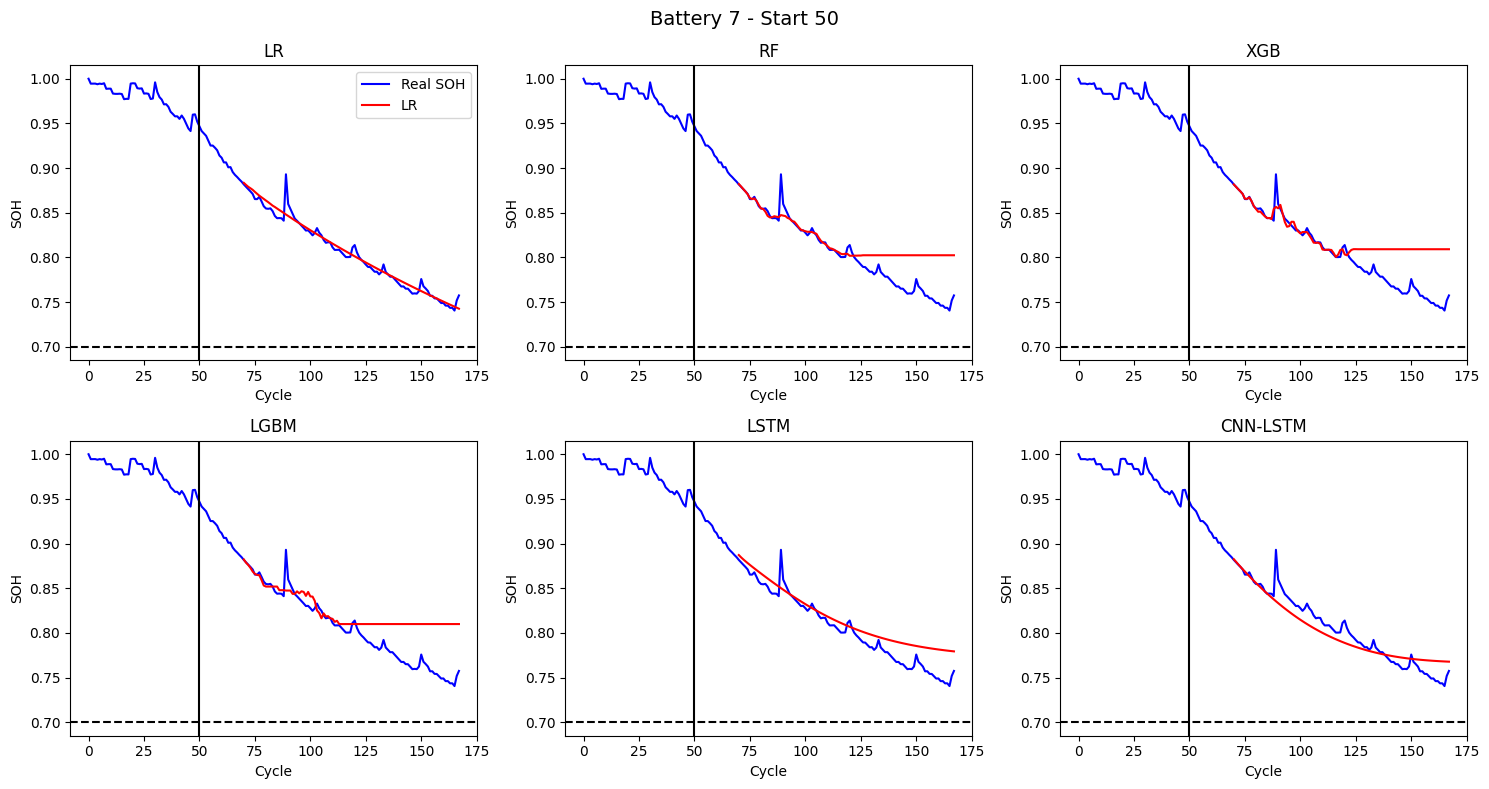

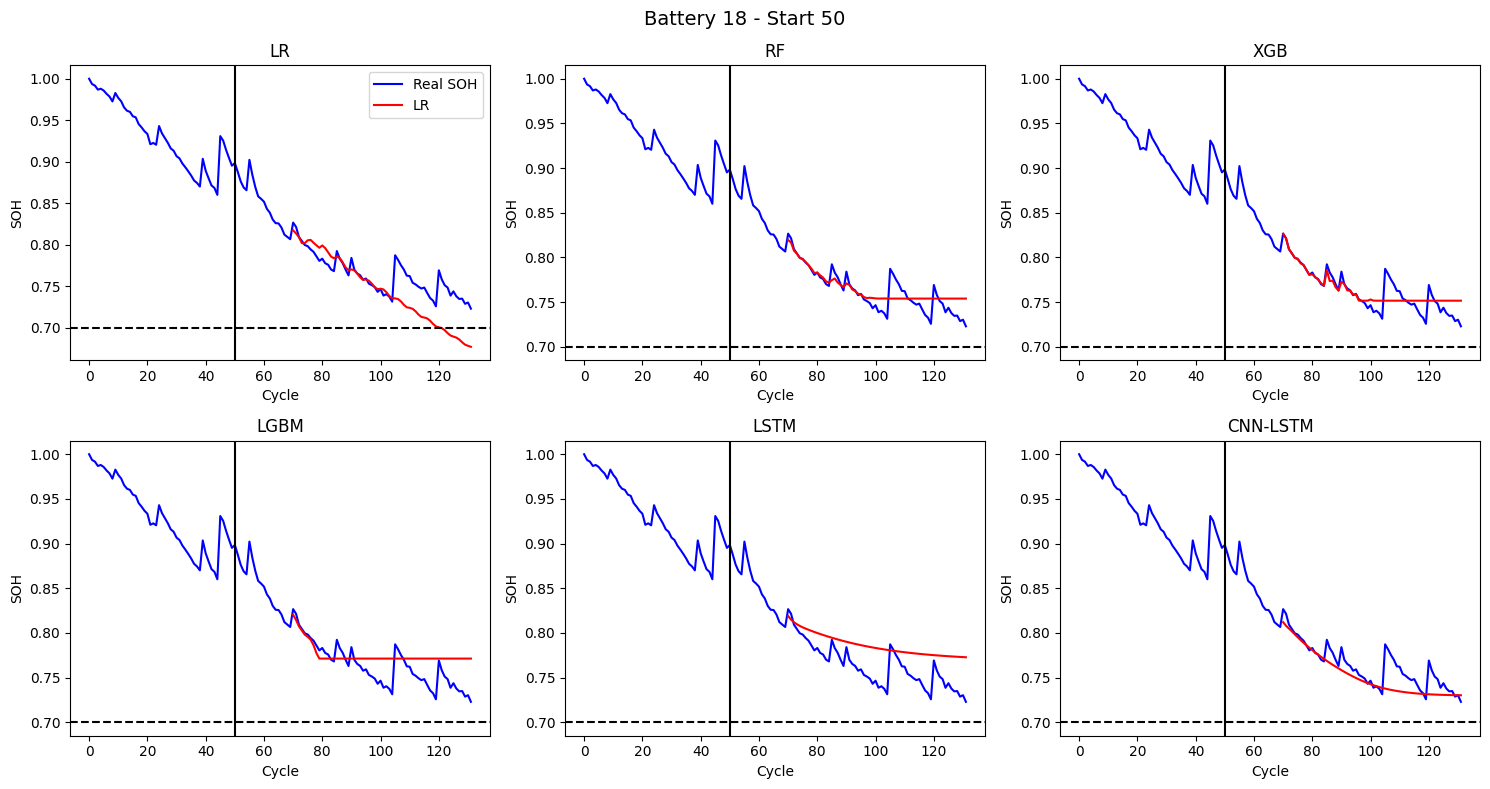

In [ ]:
plot_model_results(5, 50)
plot_model_results(6, 50)
plot_model_results(7, 50)
plot_model_results(18, 50)

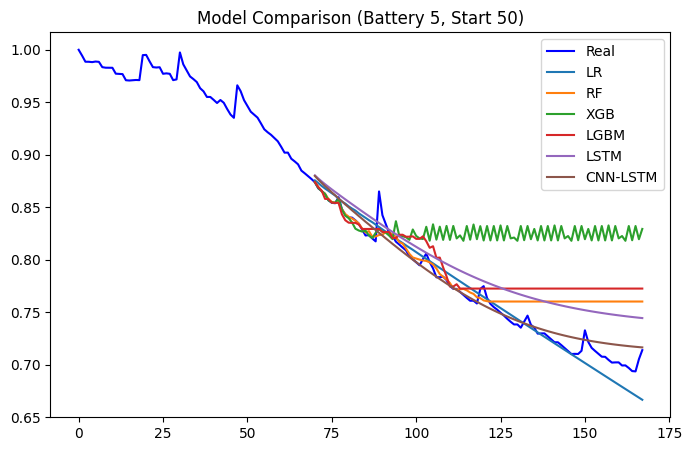

In [ ]:
# Comparision plot
battery = 5
start = 50

plt.figure(figsize=(8,5))

real = df[df['battery_num']==battery]['SOH'].values

plt.plot(real, label='Real', color='blue')

for model_name, preds in all_results[battery][start].items():
    pred_cycles = np.arange(start+window, start+window+len(preds))
    plt.plot(pred_cycles, preds, label=model_name)

plt.legend()
plt.title(f"Model Comparison (Battery {battery}, Start {start})")
plt.show()

In [ ]:
# ANN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_ann(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [ ]:
# RNN
from tensorflow.keras.layers import SimpleRNN

def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [ ]:
# Data Shaping
# ANN needs 2D input
X_train_ann = X_train.reshape(X_train.shape[0], -1)
X_test_ann  = X_test.reshape(X_test.shape[0], -1)

# RNN/LSTM need 3D input (already done in your notebook)
# shape = (samples, timesteps, features)

In [ ]:
# Training the models
# ANN
ann_model = build_ann(X_train_ann.shape[1])
history_ann = ann_model.fit(
    X_train_ann, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# RNN
rnn_model = build_rnn((X_train.shape[1], X_train.shape[2]))
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# CNN + LSTM already trained (your existing code)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 0.6189 - mae: 0.7413 - val_loss: 0.0218 - val_mae: 0.1420
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2232 - mae: 0.4276 - val_loss: 0.0012 - val_mae: 0.0282
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0557 - mae: 0.1936 - val_loss: 0.0138 - val_mae: 0.1117
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0575 - mae: 0.1917 - val_loss: 0.0312 - val_mae: 0.1720
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0919 - mae: 0.2562 - val_loss: 0.0301 - val_mae: 0.1689
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0927 - mae: 0.2556 - val_loss: 0.0204 - val_mae: 0.1381
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0462 - mae: 0.1799 - val_loss: 0.0109 - val_mae: 0.0986
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0363 - mae: 0.1613 - val_loss: 0.0044 - val_mae: 0.0588
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0310 - mae: 0.1461 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - loss: 0.3439 - mae: 0.5165 - val_loss: 0.0358 - val_mae: 0.1801
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0806 - mae: 0.2241 - val_loss: 0.1666 - val_mae: 0.4065
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0529 - mae: 0.1936 - val_loss: 0.1636 - val_mae: 0.4030
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0545 - mae: 0.1819 - val_loss: 0.0822 - val_mae: 0.2845
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0402 - mae: 0.1583 - val_loss: 0.0238 - val_mae: 0.1487
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0453 - mae: 0.1676 - val_loss: 0.0381 - val_mae: 0.1918
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0391 - mae: 0.1604 - val_loss: 0.0742 - val_mae: 0.2701
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0252 - mae: 0.1311 - val_loss: 0.0514 - val_mae: 0.2238
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0254 - mae: 0.1383 - val_loss: 0.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Avoid division by zero in MAPE
    y_safe = np.where(y == 0, 1e-8, y)
    mape = np.mean(np.abs((y - y_pred) / y_safe)) * 100

    return mae, rmse, mape

In [ ]:
# ANN
ann_mae, ann_rmse, ann_mape = evaluate_model(ann_model, X_test_ann, y_test)

# RNN
rnn_mae, rnn_rmse, rnn_mape = evaluate_model(rnn_model, X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ANN", "RNN"],
    "MAE": [ann_mae, rnn_mae],
    "RMSE": [ann_rmse, rnn_rmse],
    "MAPE (%)": [ann_mape, rnn_mape]
})

print(results)

  Model       MAE      RMSE      MAPE (%)
0   ANN  0.058209  0.067635  2.495315e+07
1   RNN  0.127615  0.156120  4.277329e+07


In [ ]:
def compute_metrics(y_true, y_pred):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    y_safe = np.where(y_true == 0, 1e-8, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_safe))

    return mape, rmse, mae

In [ ]:
def print_results(model, model_name, datasets):
    print(f"\nFINAL RESULTS - {model_name}\n")

    mape_res = []
    rmse_res = []
    mae_res = []

    for start in [50, 75, 100]:
        row_mape = []
        row_rmse = []
        row_mae = []

        for (X_test, y_test) in datasets[start]:
            y_pred = model.predict(X_test)
            mape, rmse, mae = compute_metrics(y_test, y_pred)

            row_mape.append(mape)
            row_rmse.append(rmse)
            row_mae.append(mae)

        mape_res.append(row_mape)
        rmse_res.append(row_rmse)
        mae_res.append(row_mae)

    # PRINT FORMAT EXACTLY LIKE YOUR IMAGE

    print("MAPE")
    print("Start | B5 | B6 | B7 | B18")
    for i, start in enumerate([50, 75, 100]):
        print(f"{start} | " + " | ".join(f"{v:.4f}" for v in mape_res[i]))

    print("\nRMSE")
    print("Start | B5 | B6 | B7 | B18")
    for i, start in enumerate([50, 75, 100]):
        print(f"{start} | " + " | ".join(f"{v:.4f}" for v in rmse_res[i]))

    print("\nMAE")
    print("Start | B5 | B6 | B7 | B18")
    for i, start in enumerate([50, 75, 100]):
        print(f"{start} | " + " | ".join(f"{v:.4f}" for v in mae_res[i]))

In [ ]:
def evaluate_for_cycle(model, data, start_cycle, is_ann=False):
    import numpy as np

    # Filter data based on cycle
    data_filtered = data[data['cycle'] >= start_cycle]

    # Prepare sequences (use your existing preprocessing function here)
    X, y = create_sequences(data_filtered)   # <-- YOUR FUNCTION

    # ANN needs flatten
    if is_ann:
        X = X.reshape(X.shape[0], -1)

    y_pred = model.predict(X)

    # Metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    y_safe = np.where(y == 0, 1e-8, y)
    mape = np.mean(np.abs((y - y_pred) / y_safe))

    return mape, rmse, mae

In [ ]:
def print_battery_results(model, model_name, batteries, is_ann=False):
    print(f"\nFINAL RESULTS - {model_name}\n")

    starts = [50, 75, 100]

    mape_all = []
    rmse_all = []
    mae_all = []

    for start in starts:
        mape_row, rmse_row, mae_row = [], [], []

        for battery in batteries:
            mape, rmse, mae = evaluate_for_cycle(
                model, battery, start, is_ann=is_ann
            )

            mape_row.append(mape)
            rmse_row.append(rmse)
            mae_row.append(mae)

        mape_all.append(mape_row)
        rmse_all.append(rmse_row)
        mae_all.append(mae_row)

    # PRINT LIKE YOUR IMAGE

    print("MAPE")
    print("Start | B5 | B6 | B7 | B18")
    for i, s in enumerate(starts):
        print(f"{s} | " + " | ".join(f"{v:.4f}" for v in mape_all[i]))

    print("\nRMSE")
    print("Start | B5 | B6 | B7 | B18")
    for i, s in enumerate(starts):
        print(f"{s} | " + " | ".join(f"{v:.4f}" for v in rmse_all[i]))

    print("\nMAE")
    print("Start | B5 | B6 | B7 | B18")
    for i, s in enumerate(starts):
        print(f"{s} | " + " | ".join(f"{v:.4f}" for v in mae_all[i]))